In [5]:
import numpy as np
import sympy
from sympy import symbols, Eq, linear_eq_to_matrix
import random
import matplotlib.pyplot as plt
from collections import deque, defaultdict
# from pyeda.inter import expr, exprvar, expr2bdd
# from dd.autoref import BDD
import networkx as nx
from matplotlib.colors import ListedColormap
import itertools
import pandas as pd
from sympy.logic.boolalg import SOPform
import re
import pickle
import datetime
import time
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from itertools import product
import seaborn as sns
from collections import deque


# change the code to save the data in sqlite database or pickle file to store the results
    # store number of devices in each path
    # Store currents in each path for future plots

#make code run in hipergator

#run upto 3-bit adder for optimal solution with 10 iterations and generate graphs

#############################################################################

#find and pinpoint cases that get only max zeros and min ones current

# 1 - (number of devices)
# 0 - (neighbour lrs devices to ground)
# run the simulation for only those special cases
import sys
import os
import importlib

In [6]:
# Insert the parent directory (one level up) into sys.path:
parent_dir = os.path.abspath("..")  # or an explicit path to the parent
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# First import the module in a normal way:
import PathDesignGeneration

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignGeneration)
from PathDesignGeneration import PATH

In [8]:
# Insert the parent directory (one level up) into sys.path:
parent_dir = os.path.abspath("..")  # or an explicit path to the parent
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# First import the module in a normal way:
import PathDesignGeneration

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignGeneration)
from PathDesignGeneration import PATH


lst= [1,2,3,4,5,6,7,8,9,10,12,12,13,14,15,16,17,18,19]
path_design_lst = []

filename_lst = {str(i)+"-bitAdder":"../bdds/"+str(i)+"-bitAdder.sbdd" for i in lst}
# with open("Data/truth_tables_data.pkl", "rb") as f:
#     truth_tables_data = pickle.load(f)

Functional_Logic_Of_Path_Crossbar_Programings = {}
nadder = 1
for adderbit in lst:
    start_time = time.time()
    adder_index = adderbit-1
    filename = filename_lst[str(adderbit)+'-bitAdder']

    # if(adderbit<10):
    #     outputs, df = truth_tables_data[str(adderbit)+'-bitAdder']["outputs"], truth_tables_data[str(adderbit)+'-bitAdder']["TruthTable_df"]
    # else:
    #     outputs, df = None, None
        
    path = PATH(CrossbarGridSize = 100)
    # path.TruthTable_to_BooleanExpression(df, outputs=outputs)
    # path.BooleanExpresions_to_BDD()
    # print("----------------------------------------------------------------------------------------------")
    # expressions = {'F0' : '(a & b) | (a & cin) | (b & cin)',
    # 'F1' : '(a & b & cin) | (a & ~b & ~cin) | (b & ~a & ~cin) | (cin & ~a & ~b)'}
    # variables = ['a', 'b', 'cin']
    # path.SetBooleanExpressionsAndVaribles(variables = variables, expressions = expressions, outputs = list(expressions.keys()))
    # print("----------------------------------------------------------------------------------------------")
    
    # path.SetBooleanExpressionsAndVaribles(variables = None, expressions = None, outputs = outputs, OriginalTruthTable=df)
    path.parse_file_to_NetworkXGraph(filename)
    path.BDD_to_NetworkXGraph()
    # if(adderbit<5):
    #     path.Verify_BDD_to_NetworkXGraph(withExpression=False, withOriginalTruthTable=False, generateFromBDD=True)
    # path.VisuvaliseNetworkXGraph()
    # print("----------------------------------------------------------------------------------------------")
    path.GraphPreprocessing()
    # if(adderbit==1):
    #     path.VisuvaliseNetworkXGraph()
    # print("----------------------------------------------------------------------------------------------")
    path.GraphTransformation()
    # path.VisuvaliseNetworkXGraph(bipartite=True)
    # print("----------------------------------------------------------------------------------------------")
    path.GraphCompression()
    # if(adderbit==1):
    #     path.VisuvaliseNetworkXGraph(bipartite=True)
    # print("----------------------------------------------------------------------------------------------")

    # path.GraphSplittingWithHeightConstraint(height=10)
    path.GraphSplittingWithHeightConstraint(height=6)

    path.GraphAddRootNodeToInputLines()
    
    path.GraphSplittinWithSizeConstraint(size=64)
    # path.GraphSplittinWithSizeConstraint(size=128)

    path.CrossbarDesignRelalization()

    path_design_lst.append(path)

    # path.InferPrerequisiteTrees()

    # print('path.Processed_graphs_Map', path.Processed_graphs_Map.keys())

    # print('path.Processed_graphs_Map[None]',path.Processed_graphs_Map[None])

    # print('path.output_node_index',path.output_node_index)

    # rows, cols, count = 0, 0, 0
    # dimMap = {}
    # for key in path.Processed_graphs_Map:
    #     row = len(path.Processed_graphs_Map[key]['Crossbar_design'])
    #     col = len(path.Processed_graphs_Map[key]['Crossbar_design'][0])

    #     if(f'{row}x{col}' not in dimMap):
    #         dimMap[f'{row}x{col}'] = 0
    #     dimMap[f'{row}x{col}']+=1
    #     rows+=row
    #     cols+=col
    #     count+=1

    # print('Total = rows x cols:', rows,"x", cols, "count:", count)
    # print(dimMap)

    # Functional_Logic_Of_Path_Crossbar_Programings[str(adderbit)+'-bitAdder'] = {'Crossbar':path.CrossbarResistiveStates, 'Bitlines':path.Bitlines, 'TruthTable':path.OriginalTruthTable, 'OutputLine_Map':path.OutputLine_Map, 'AdderBit':str(adderbit)+'-bitAdder', 'SBDD (V x E)':path.SBDD_dimentions}
    
    print(f"{adderbit}-bit Adder took {time.time() - start_time:.6f} seconds")

    # print('path.CrossbarLongPaths',path.CrossbarLongPaths)
    print()
    print("_________________________________________________________________________")
    if(adderbit==5):
        break

# Save (pickle) to a file
# with open("Data/Functional_Logic_Of_Path_Crossbar_Programings.pkl", "wb") as f:
#     pickle.dump(Functional_Logic_Of_Path_Crossbar_Programings, f)
# print("Data saved to multi_data.pkl")

1-bit Adder took 0.003008 seconds

_________________________________________________________________________
2-bit Adder took 0.007004 seconds

_________________________________________________________________________
3-bit Adder took 0.013997 seconds

_________________________________________________________________________
4-bit Adder took 0.037120 seconds

_________________________________________________________________________
5-bit Adder took 0.092782 seconds

_________________________________________________________________________


In [9]:
path.Topological_order

[(frozenset(), 0),
 (frozenset(), 1),
 (frozenset({'12ec9e54-67ee-4a78-9484-41821ba2d7b5',
             '3357bb47-ad50-4cfc-ac09-89009826f90d',
             '3aea2d6e-8ccd-4c39-8541-2d2e9cacc117',
             '42e5c6dd-41e2-467b-9531-61763acf9a5f',
             '4671f9d9-ac90-45a6-846d-3f681f17e738',
             '60ab678d-2440-4ed9-8022-469b389749cc',
             '664fca3b-9ba7-4cf1-a8cd-0e9550be3f3f',
             '79d0d0ff-b718-42c6-9ff2-2b700d080088',
             '9b8e21ed-2f52-48fd-89e5-7563a7da3ac2',
             'b1a93c26-03fe-4a83-9902-4858913e2247',
             'b1e0571c-ca00-41d9-a75f-66c8a65b8be0',
             'b3f52192-f1e3-4b59-b514-5573e5a57ba3',
             'b8c04180-cbba-4f2e-8a3a-f45b020af42d',
             'dfcd86d4-ca47-43d6-81a0-9a94cc16c2c5',
             'e6e1032e-b449-4bc0-a54e-c8436e67aceb',
             'e911b0a7-687f-4c48-939d-1a63f79774de'}),
  0),
 (frozenset({'2765ee33-cf73-43bd-9f4f-a036880f4cae',
             '3f7fdb1e-4f8e-43b6-829a-bc5b5ec138f9',


O10 out_split_id 42e5c6dd-41e2-467b-9531-61763acf9a5f
O4 out_split_id b1a93c26-03fe-4a83-9902-4858913e2247


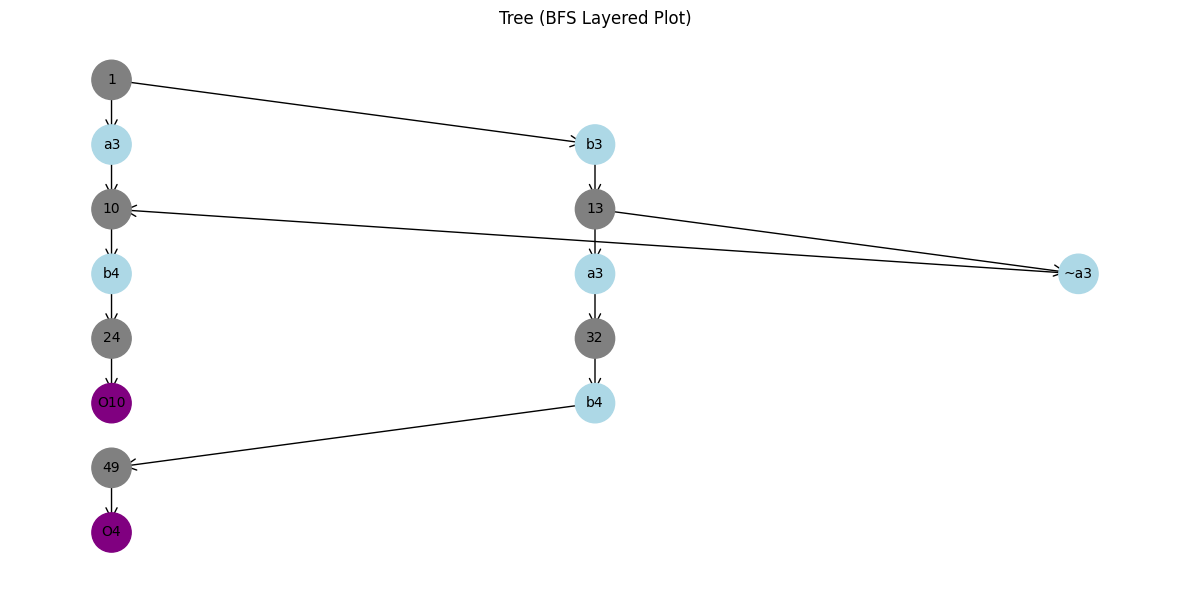

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, deque

def plot_tree_bfs_layered(G, node_labels=True, edge_labels=False, title="Tree (BFS Layered Plot)", debug=False):
    # Step 1: Find the root node (U1 node with no predecessors)
    # Step 1: Find all root nodes (U1 nodes with no predecessors)
    roots = [
        node for node in G.nodes
        if G.nodes[node].get("BipartitePart") == "U1" and G.in_degree(node) == 0
    ]
    if not roots:
        raise ValueError("No root nodes found (U1 nodes with no predecessors)")

    # Step 2: BFS from all roots to assign levels
    levels = {root: 0 for root in roots}
    layer_nodes = defaultdict(list)
    queue = deque(roots)

    for root in roots:
        layer_nodes[0].append(root)

    while queue:
        node = queue.popleft()
        level = levels[node]

        for succ in G.successors(node):
            if succ not in levels:
                levels[succ] = level + 1
                layer_nodes[level + 1].append(succ)
                queue.append(succ)

    # Step 3: Assign positions
    pos = {}
    x_gap = 2.5
    y_gap = 1.5
    for level, nodes in layer_nodes.items():
        for i, node in enumerate(nodes):
            pos[node] = (i * x_gap, -level * y_gap)

    # Step 4: Assign positions to unplaced nodes (unreachable from root)
    unplaced_nodes = [node for node in G.nodes if node not in pos]
    if unplaced_nodes:
        extra_level = max(layer_nodes.keys(), default=0) + 1
        for i, node in enumerate(unplaced_nodes):
            pos[node] = (i * x_gap, -extra_level * y_gap)

    # Step 5: Determine node colors
    node_colors = []
    for node in G.nodes:
        if node in unplaced_nodes:
            node_colors.append('red')
        else:
            literal = G.nodes[node].get('literal', '')
            in_split_ids = G.nodes[node].get('in_split_id',set())
            out_split_id = G.nodes[node].get('out_split_id',None)
            if(in_split_ids != set()):
                if(debug):
                    print(literal, 'in_split_ids',in_split_ids)
            if(out_split_id != None):
                if(debug):
                    print(literal, 'out_split_id',out_split_id)
            if out_split_id != None:
                node_colors.append('purple')
            elif len(in_split_ids)>0:
                node_colors.append('lime')
            elif 'O' in literal:
                node_colors.append('orange')
            elif literal.isdigit():
                node_colors.append('grey')
            else:
                node_colors.append('lightblue')

    # Step 6: Draw the graph
    plt.figure(figsize=(12, 6))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='->', arrowsize=20)

    if node_labels:
        labels = {n: G.nodes[n].get('literal', str(n)) for n in G.nodes}
        nx.draw_networkx_labels(G, pos, labels, font_size=10)

    if edge_labels:
        edge_lbls = {(u, v): d.get('condition', '') for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_lbls, font_size=8)

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

for i,key in enumerate(path.Processed_group_graphs_Map):
    # if(i not in [2,4,5,7,9,10,11,12]):
    #     continue
    # for row in path.Processed_graphs_Map[key]['Crossbar_design']:
    #     print(row)
    # print(path.Processed_graphs_Map[key]['Selector_Lines_Map'])
    # print(key, i)
    # print(path.Processed_group_graphs_Map[key]['OutputLine_group_Map'])
    # print(key)
    if(i!=1):
        continue
    plot_tree_bfs_layered(
        path.Processed_group_graphs_Map[key]['processed_group_graph'],
        debug=True
    )

In [11]:
for design_ID_group in path.Processed_group_graphs_Map:
    print()
    print(path.Processed_group_graphs_Map[design_ID_group].keys())
    print(sorted(path.Processed_group_graphs_Map[design_ID_group]['OutputLine_group_Map'].keys()))
    print(sorted(path.Processed_group_graphs_Map[design_ID_group]['OutputLine_group_selectorLines_Map'].keys()))
    print(path.Processed_group_graphs_Map[design_ID_group]['OutputLine_group_selectorLines_Map'])


dict_keys(['processed_group_graph', 'OutputLine_group_Map', 'OutputLine_group_selectorLines_Map', 'BDD_dimentions', 'Selector_Lines_Map', 'Crossbar_design', 'DesignIdItemToWordLineInputMap', 'LongestPaths', 'Crossbar_disabledOutputsToInputs'])
['O0', 'O1', 'O11', 'O12', 'O13', 'O14', 'O15', 'O16', 'O17', 'O18', 'O2', 'O3', 'O5', 'O6', 'O7', 'O8', 'O9']
['O0', 'O1', 'O11', 'O12', 'O13', 'O14', 'O15', 'O16', 'O17', 'O18', 'O2', 'O3', 'O5', 'O6', 'O7', 'O8', 'O9']
{'O0': [33, 47, 25, 1, 26, 7, 31, 3, 40], 'O1': [46, 48, 38, 2, 16, 9, 30, 23], 'O2': [46, 36, 49, 38, 30, 9, 23, 21], 'O3': [13, 8, 30, 32, 11, 50, 23, 22], 'O5': [46, 29, 16, 51, 23], 'O6': [17, 28, 4, 0, 6, 27, 20, 52, 12], 'O7': [46, 13, 38, 30, 53, 18, 39, 23, 22], 'O8': [44, 42, 54, 26, 10, 3, 33], 'O9': [55, 14, 7, 15, 31, 40, 43], 'O11': [29, 13, 32, 56, 41, 23], 'O12': [13, 30, 41, 32, 57, 23, 22, 34], 'O13': [45, 46, 30, 58, 23, 22], 'O14': [17, 19, 28, 59, 0, 4], 'O15': [35, 13, 60, 38, 30, 23], 'O16': [61, 4, 0, 12,

In [12]:
# First import the module in a normal way:
import PathDesignLogicalVerification

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignLogicalVerification)
from PathDesignLogicalVerification import PATH_Design_Logic_Verification, Bus

for node in path.Processed_group_graphs_Map:
    # for row in path.Processed_graphs_Map[node]['Crossbar_design']:
    #     print(row)
    # print(path.Processed_graphs_Map[node]['Selector_Lines_Map'])
    # print(path.Processed_graphs_Map[node]['OutputLine_Map'])
    # print()
    # print(path.Processed_graphs_Map[node]['BDD_dimentions'])
    # print(path.Processed_graphs_Map[node]['LongestPath'])
    # print(path.Processed_graphs_Map[node]['DesignIdItemToWordLineInputMap'])
    # print(path.Processed_graphs_Map[node]['PrerequisiteTrees'])
    print('------------------------------------------------')

CrossbarGridSize = 64

for i,path in enumerate(path_design_lst):

    bus = Bus(MainBDD_For_GoldenModel = path.Graph, Topological_order = path.Topological_order)
    
    total_rows = 0
    total_cols = 0
    Processed_group_graphs_Map = {}
    for design_ID in path.Processed_group_graphs_Map:
        m = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'])
        n = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'][0])
        if(total_rows+m <= CrossbarGridSize and total_cols+n <= CrossbarGridSize):
            Processed_group_graphs_Map[design_ID] = path.Processed_group_graphs_Map[design_ID]
            total_rows += m
            total_cols += n
        else:
            path_functional_verification = PATH_Design_Logic_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)
            Processed_group_graphs_Map = {design_ID: path.Processed_group_graphs_Map[design_ID]}
    if(len(Processed_group_graphs_Map)):
        path_functional_verification = PATH_Design_Logic_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)
    
    print('NumberOfDesigns:', bus.getNumberOfDesigns())
    print('NumberOfCrossbars:', bus.getNumberOfCrossbars())
    
    test_results = bus.RunRandomTestCases(num_tests=40, RunAllTests=False)
    print('----------------------------------------------')

    


# OutputLine_group_selectorLines_Map

------------------------------------------------
------------------------------------------------
NumberOfDesigns: 1
NumberOfCrossbars: 1
______________________________________
[✅] Test 1 Passed {'cout': 0, 'sum0': 1}
______________________________________
______________________________________
[✅] Test 2 Passed {'cout': 0, 'sum0': 1}
______________________________________
______________________________________
[✅] Test 3 Passed {'cout': 0, 'sum0': 1}
______________________________________
______________________________________
[✅] Test 4 Passed {'cout': 0, 'sum0': 1}
______________________________________
______________________________________
[✅] Test 5 Passed {'cout': 1, 'sum0': 0}
______________________________________
______________________________________
[✅] Test 6 Passed {'cout': 0, 'sum0': 1}
______________________________________
______________________________________
[✅] Test 7 Passed {'cout': 0, 'sum0': 0}
______________________________________
_____________________________

In [61]:
# First import the module in a normal way:
import PathDesignAnalogVerification

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignAnalogVerification)
from PathDesignAnalogVerification import PATH_Design_Analog_Verification, Bus

for node in path.Processed_group_graphs_Map:
    # for row in path.Processed_graphs_Map[node]['Crossbar_design']:
    #     print(row)
    # print(path.Processed_graphs_Map[node]['Selector_Lines_Map'])
    # print(path.Processed_graphs_Map[node]['OutputLine_Map'])
    # print()
    # print(path.Processed_graphs_Map[node]['BDD_dimentions'])
    # print(path.Processed_graphs_Map[node]['LongestPath'])
    # print(path.Processed_graphs_Map[node]['DesignIdItemToWordLineInputMap'])
    # print(path.Processed_graphs_Map[node]['PrerequisiteTrees'])
    print('------------------------------------------------')

bus_lst = []

for i,path in enumerate(path_design_lst):
    if(i not in [7]):
        continue
    CrossbarGridSize = 64
    bus = Bus(MainBDD_For_GoldenModel = path.Graph, Topological_order = path.Topological_order)
    total_rows = 0
    total_cols = 0
    Processed_group_graphs_Map = {}
    for design_ID in path.Processed_group_graphs_Map:
        m = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'])
        n = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'][0])
        if(total_rows+m <= CrossbarGridSize and total_cols+n <= CrossbarGridSize):
            Processed_group_graphs_Map[design_ID] = path.Processed_group_graphs_Map[design_ID]
            total_rows += m
            total_cols += n
        else:
            path_analog_verification = PATH_Design_Analog_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)
            Processed_group_graphs_Map = {design_ID: path.Processed_group_graphs_Map[design_ID]}
    if(len(Processed_group_graphs_Map)):
        path_analog_verification = PATH_Design_Analog_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)
    
    bus.CalibrateHRSValues(Optimisation=True, max_iterations=1)
    
    bus_lst.append(bus)
    print('------------------------------------------------',i)

------------------------------------------------
------------------------------------------------
------------------------------------------------
------------------------------------------------
------------------------------------------------
------------------------------------------------
------------------------------------------------
------------------------------------------------
------------------------------------------------
------------------------------------------------
------------------------------------------------
------------------------------------------------
------------------------------------------------
------------------------------------------------
------------------------------------------------
-------------------------------------------------------------------
design_ID_group (frozenset(), 0)
start zero
ZerosCurrent 6.586105848873686e-06
ZerosCurrent1 6.251826868971054e-06
guardBound 0.027392041367845652
R_HRS 5000000000.0
design_ID_group (frozenset(), 0

In [ ]:
0 - 15 16 17 18
13 - 27 28

In [64]:
failuresOfWorstcase0 = 0
failuresOfWorstcase1 = 0

adder_dict = {}

for i,bus in enumerate(bus_lst):
    if(i not in [0]):
        continue
    
    print('design start i:',i)

    if(i in [0,1]):
        test_results = bus.RunRandomTestCases(num_tests=100, RunAllTests=False)
    # else:
        # test_results = bus.RunRandomTestCases(num_tests=1000, RunAllTests=False)
    
    # bus.ExecuteDesignsInTopologicalOrder({'a2': 0, 'a4': 0, 'a3': 0, 'a6': 0, 'b2': 0, 'b6': 1, 'b4': 0, 'b5': 0, 'b3': 0, 'b1': 0, 'b0': 0, 'a5': 0, 'cin': 0, 'a1': 1, 'a0': 0})
    
    currentFlag = False
    for design_ID in bus.OnesCurrentFromDesignMap:
        minOnesCurrent = min(bus.OnesCurrentFromDesignMap[design_ID],default=1)
        maxZerosCurrent = max(bus.ZerosCurrentFromDesignMap[design_ID],default=0)
        print()
        print(f"maxZerosCurrent: {maxZerosCurrent}")
        print(f"minOnesCurrent : {minOnesCurrent}")
        
        if(maxZerosCurrent-bus.WorstCaseMaxZero[design_ID]>0):
            print(f"Worst case approximation is not working 0 for {design_ID}")
            print(f"{bus.WorstCaseMaxZero[design_ID]} < {maxZerosCurrent}")
            print("worst max 0 < current")
            failuresOfWorstcase0+=1
        
        if(bus.WorstCaseMinOne[design_ID]-minOnesCurrent>1e-6):
            print(f"Worst case approximation is not working 1 for {design_ID}")
            print(f"{bus.WorstCaseMinOne[design_ID]} > {minOnesCurrent}")
            print("worst min 1 > current")
            failuresOfWorstcase1+=1

    adder_dict[f"{i+1}-bitAdder"] = {
        "worst0":bus.WorstCaseMaxZero[design_ID],
        "worst1":bus.WorstCaseMinOne[design_ID],
        "zeroCurrentlst":bus.ZerosCurrentFromDesignMap[design_ID],
        "oneCurrentlst":bus.OnesCurrentFromDesignMap[design_ID],
    }

design start i: 0
______________________________________
[✅] Test 1 Passed {'sum6': 0, 'sum7': 0, 'cout': 0, 'sum4': 0, 'sum2': 0, 'sum5': 0, 'sum3': 0, 'sum1': 0, 'sum0': 0}
______________________________________
______________________________________
[✅] Test 2 Passed {'sum6': 0, 'sum7': 0, 'cout': 1, 'sum4': 0, 'sum2': 1, 'sum5': 0, 'sum3': 0, 'sum1': 0, 'sum0': 0}
______________________________________
______________________________________
[✅] Test 3 Passed {'sum6': 1, 'sum7': 1, 'cout': 0, 'sum4': 1, 'sum2': 1, 'sum5': 0, 'sum3': 1, 'sum1': 1, 'sum0': 0}
______________________________________
______________________________________
[✅] Test 4 Passed {'sum6': 0, 'sum7': 0, 'cout': 1, 'sum4': 0, 'sum2': 0, 'sum5': 0, 'sum3': 0, 'sum1': 0, 'sum0': 1}
______________________________________
______________________________________
[✅] Test 5 Passed {'sum6': 1, 'sum7': 1, 'cout': 0, 'sum4': 0, 'sum2': 1, 'sum5': 0, 'sum3': 0, 'sum1': 1, 'sum0': 1}
______________________________________
__

In [223]:
failuresOfWorstcase0, failuresOfWorstcase1

(2, 0)

R_H / CS > h x (R_L)
h is path length (h/2 is number of boolean varibles processed) <br>
R_H is the H.R.S resitance value <br>
R_L is the L.R.S resitance value <br>
CS is crossbar size (can only be in denominations of 2^n) <br>

R_H / CS > h x R_L <br>
R_H / R_L > h x CS <br>
R_L / R_H < 1 / h x CS <br>
<br>
let CS=64, h=7 <br>
<br>
R_L / R_H < 1 / 64 x 7 <br>
R_L / R_H < 1 / 448

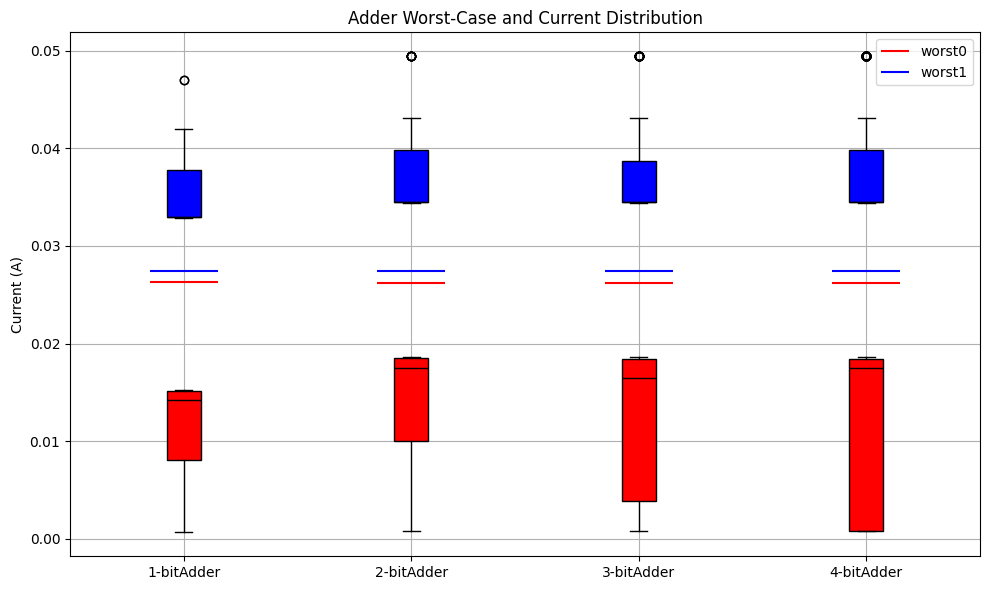

In [159]:
import matplotlib.pyplot as plt
import numpy as np

# Sample mock data for illustration (replace with actual adder_dict data)
# adder_dict = {
#     '1-bitAdder': {
#         'worst0': 0.0035,
#         'worst1': 0.008,
#         'zeroCurrentlst': [0.0025, 0.0027, 0.0031, 0.0030, 0.0032,0.0025, 0.0027, 0.0031, 0.0030, 0.0032, 0.0025, 0.0027, 0.0031, 0.0030, 0.0002, 0.0001, 0.0002],
#         'oneCurrentlst': [0.0085, 0.0087, 0.0092, 0.0090, 0.0091]
#     },
#     '2-bitAdder': {
#         'worst0': 0.004,
#         'worst1': 0.010,
#         'zeroCurrentlst': [0.0038, 0.0041, 0.0040, 0.0042, 0.0039],
#         'oneCurrentlst': [0.0095, 0.0097, 0.0102, 0.0098, 0.0101]
#     },
#     '3-bitAdder': {
#         'worst0': 0.005,
#         'worst1': 0.011,
#         'zeroCurrentlst': [0.0049, 0.0050, 0.0051, 0.0052, 0.0050],
#         'oneCurrentlst': [0.0105, 0.0107, 0.0112, 0.0109, 0.0110]
#     }
# }

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
positions = []
labels = []
width = 0.2
i = 1

for key in adder_dict:
    adder = adder_dict[key]
    
    # Candle/Box plots for zeroCurrentlst and oneCurrentlst
    box_data = [adder['zeroCurrentlst'], adder['oneCurrentlst']]
    box_positions = [i, i]
    box = ax.boxplot(box_data, positions=box_positions, widths=0.15, patch_artist=True)

    colors = ['red', 'blue']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)

    for median in box['medians']:
        median.set_color('black')

    # Line plots for worst0 (red) and worst1 (blue)
    # ax.plot([i], [adder['worst0']], 'ro', label='worst0' if i == 1 else "")
    # ax.plot([i], [adder['worst1']], 'bo', label='worst1' if i == 1 else "")

    # Replace dot markers with short horizontal lines for worst0 and worst1
    line_length = 0.3  # adjust as needed
    ax.hlines(y=adder['worst0'], xmin=i - line_length/2, xmax=i + line_length/2, colors='red', label='worst0' if i == 1 else "")
    ax.hlines(y=adder['worst1'], xmin=i - line_length/2, xmax=i + line_length/2, colors='blue', label='worst1' if i == 1 else "")

    positions.append(i)
    labels.append(key)
    i += 1

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_title('Adder Worst-Case and Current Distribution')
ax.set_ylabel('Current (A)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()